ROP RECOMMENDATION SYSTEM
 Agricultural Machine Learning Pipeline
=============================================================================
 Business Objective:
   Precision agriculture depends on data-driven decisions to maximize yield
   and optimize resource usage. This pipeline ingests IoT soil and climate
   sensor data and trains a multi-class classification model to recommend
   the optimal crop for a given farming environment across 22 crop types.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
 
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
 
import warnings
warnings.filterwarnings("ignore")
 
# Global plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

In [27]:
# STEP 1 -- DATA INGESTION AND HEALTH CHECK
print("  STEP 1 -- DATA INGESTION AND HEALTH CHECK")
 
# Load the dataset
df = pd.read_csv("Crop_recommendation.csv")
 
# 1a. Basic structure 
print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
 
print("\n--- Column Data Types ---")
print(df.dtypes)
 
print("\n--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values detected.")
 
print("\n--- Duplicate Rows ---")
dupes = df.duplicated().sum()
print(f"{dupes} duplicate row(s) found." if dupes > 0 else "No duplicate rows.")
 
print("\n--- First 5 Rows ---")
print(df.head())

  STEP 1 -- DATA INGESTION AND HEALTH CHECK

--- Dataset Shape ---
Rows: 2,200  |  Columns: 8

--- Column Data Types ---
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

--- Missing Values ---
No missing values detected.

--- Duplicate Rows ---
No duplicate rows.

--- First 5 Rows ---
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [28]:
#  1b. Statistical summary
print("\n--- Descriptive Statistics (Numerical Features) ---")
print(df.describe().round(2))
 
# 1c. Target class summary 
print(f"\n--- Target Variable: 'label' ---")
print(f"Unique crop types : {df['label'].nunique()}")
print(f"Class distribution (should be balanced):\n{df['label'].value_counts()}")


--- Descriptive Statistics (Numerical Features) ---
             N        P        K  temperature  humidity       ph  rainfall
count  2200.00  2200.00  2200.00      2200.00   2200.00  2200.00   2200.00
mean     50.55    53.36    48.15        25.62     71.48     6.47    103.46
std      36.92    32.99    50.65         5.06     22.26     0.77     54.96
min       0.00     5.00     5.00         8.83     14.26     3.50     20.21
25%      21.00    28.00    20.00        22.77     60.26     5.97     64.55
50%      37.00    51.00    32.00        25.60     80.47     6.43     94.87
75%      84.25    68.00    49.00        28.56     89.95     6.92    124.27
max     140.00   145.00   205.00        43.68     99.98     9.94    298.56

--- Target Variable: 'label' ---
Unique crop types : 22
Class distribution (should be balanced):
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         1

In [29]:
# STEP 2 -- EXPLORATORY DATA ANALYSIS
print("  STEP 2 -- EXPLORATORY DATA ANALYSIS")
 
FEATURE_COLS = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
FEATURE_LABELS = {
    "N": "Nitrogen (N)",
    "P": "Phosphorus (P)",
    "K": "Potassium (K)",
    "temperature": "Temperature (°C)",
    "humidity": "Humidity (%)",
    "ph": "Soil pH",
    "rainfall": "Rainfall (mm)",
}

  STEP 2 -- EXPLORATORY DATA ANALYSIS


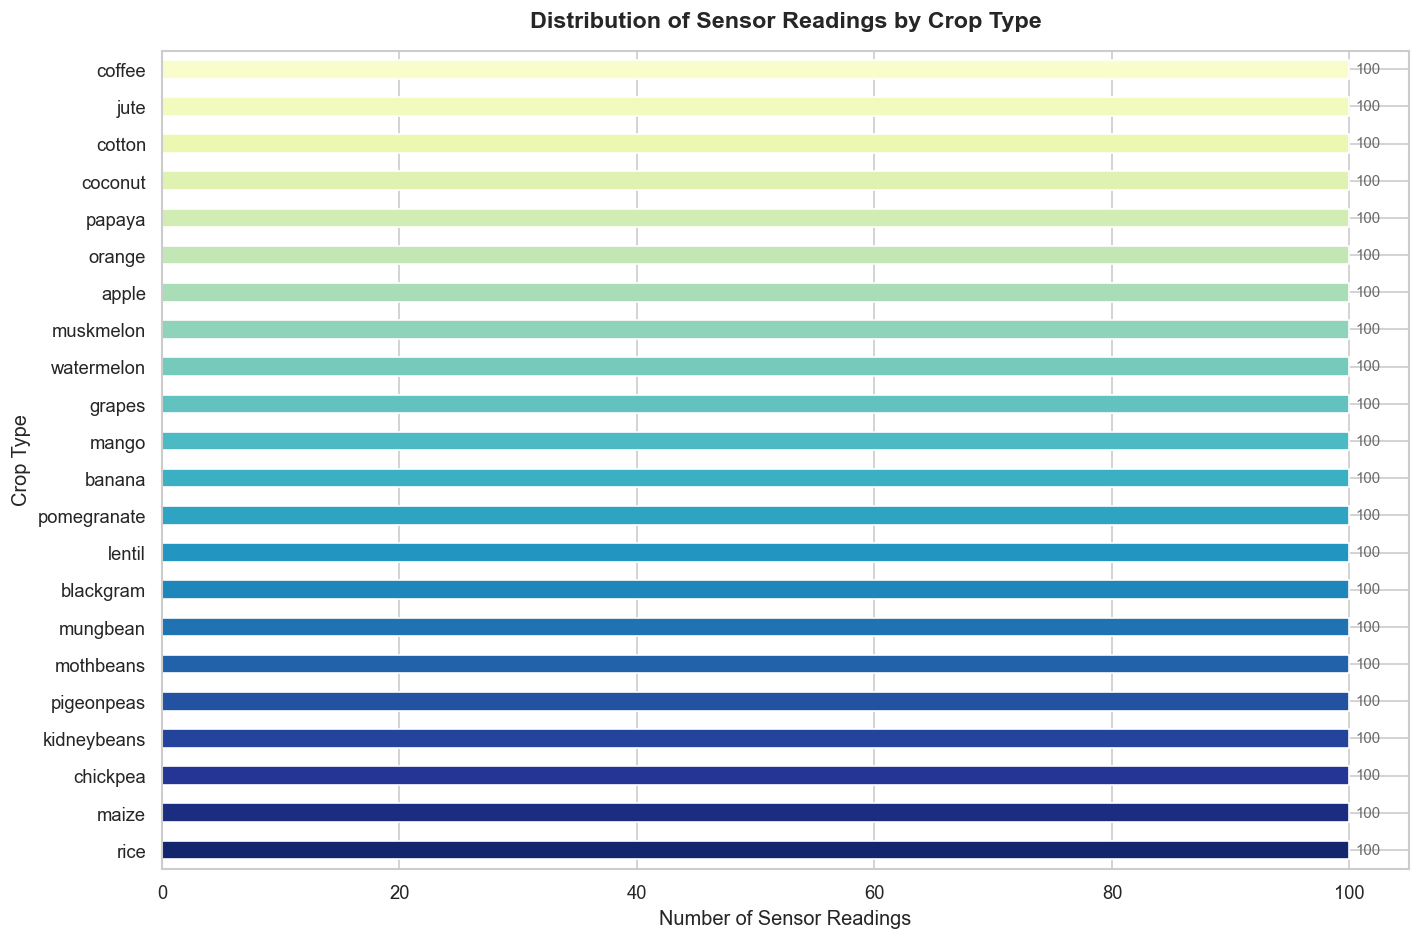


[Insight] The dataset is perfectly balanced: exactly 100 readings per crop type across 22 crops. This eliminates class-imbalance bias from the classifier before any training begins.


In [30]:
#  2a. Crop distribution 
fig, ax = plt.subplots(figsize=(12, 8))
crop_counts = df["label"].value_counts()
colors = sns.color_palette("YlGnBu", len(crop_counts))[::-1]
crop_counts.sort_values().plot(kind="barh", ax=ax, color=colors)
 
ax.set_title("Distribution of Sensor Readings by Crop Type", pad=14)
ax.set_xlabel("Number of Sensor Readings")
ax.set_ylabel("Crop Type")
 
# Annotate count on each bar
for patch in ax.patches:
    ax.text(
        patch.get_width() + 0.5, patch.get_y() + patch.get_height() / 2,
        f"{int(patch.get_width())}",
        va="center", fontsize=9, color="dimgray",
    )
 
plt.tight_layout()
plt.savefig("plot_01_crop_distribution.png")
plt.show()
 
print(
    "\n[Insight] The dataset is perfectly balanced: exactly "
    f"{crop_counts.iloc[0]} readings per crop type across "
    f"{len(crop_counts)} crops. This eliminates class-imbalance bias "
    "from the classifier before any training begins."
)

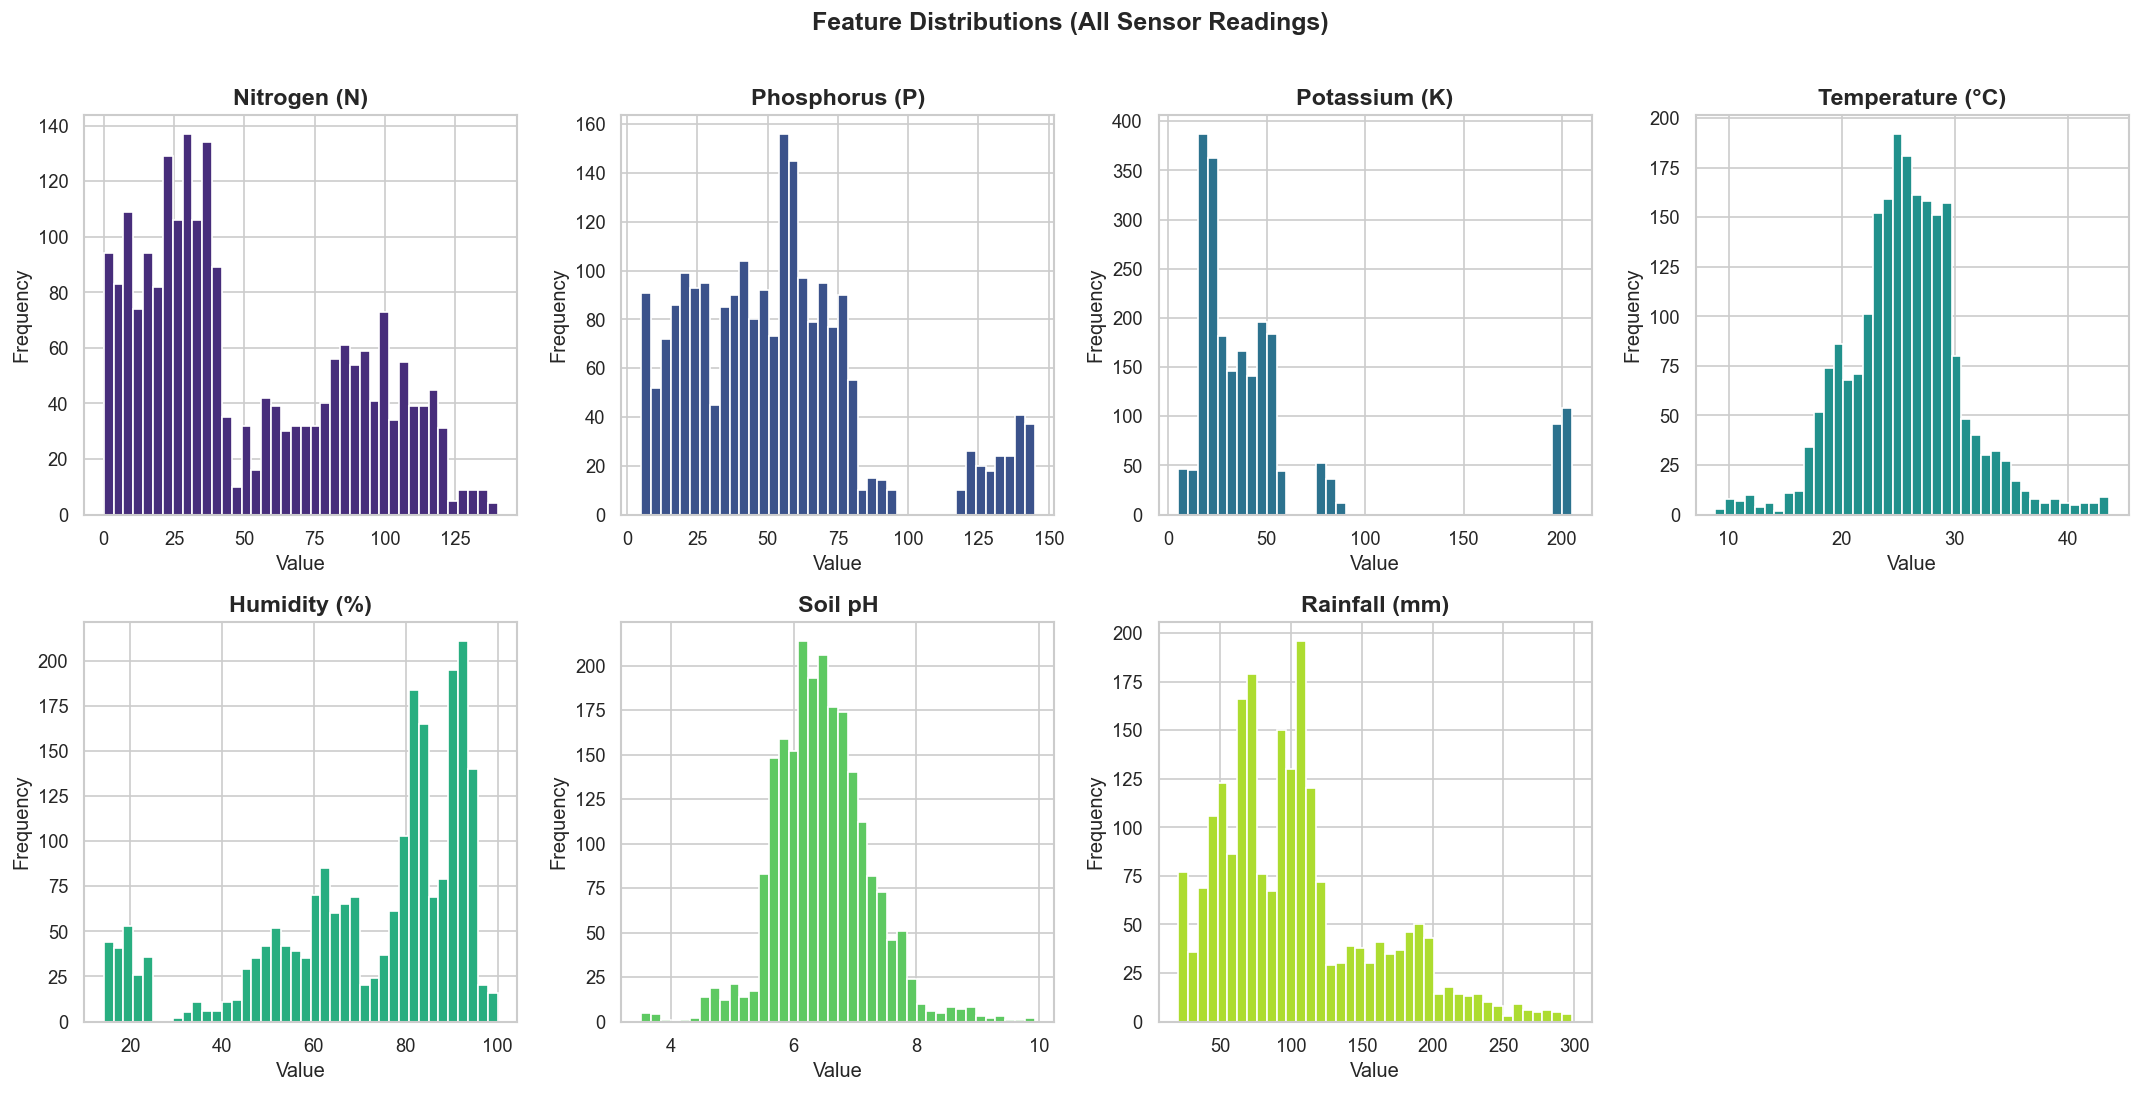

In [31]:
#  2b. Feature distributions (histograms) 
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
 
for i, col in enumerate(FEATURE_COLS):
    axes[i].hist(df[col], bins=40, color=sns.color_palette("viridis", 7)[i], edgecolor="white")
    axes[i].set_title(FEATURE_LABELS[col])
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
 
axes[-1].set_visible(False)  # hide the empty 8th subplot
fig.suptitle("Feature Distributions (All Sensor Readings)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_02_feature_distributions.png")
plt.show()

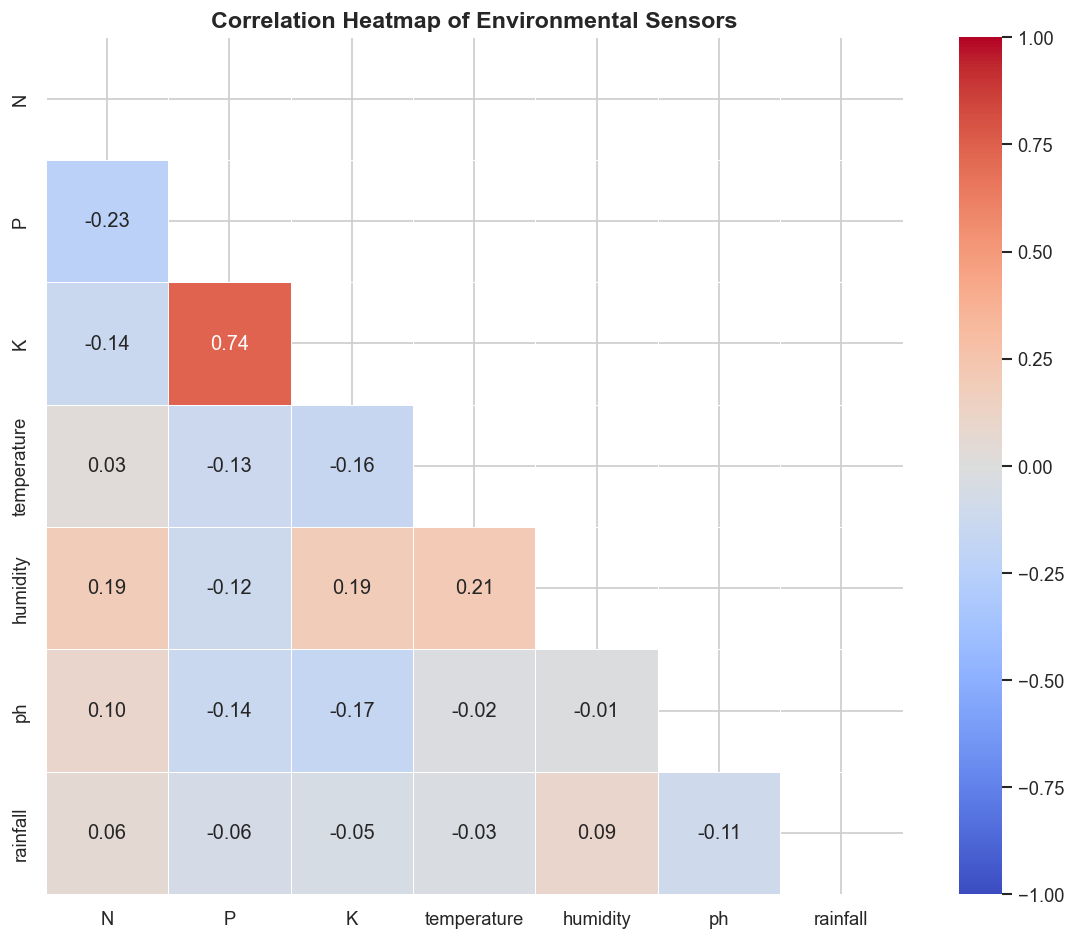

In [32]:
#  2c. Correlation heatmap 
plt.figure(figsize=(10, 8))
corr_matrix = df[FEATURE_COLS].corr()
 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # show only lower triangle
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    mask=mask,
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("Correlation Heatmap of Environmental Sensors")
plt.tight_layout()
plt.savefig("plot_03_correlation_heatmap.png")
plt.show()

Insight: Phosphorus (P) and Potassium (K) carry the strongest 
    positive correlation (0.74), indicating these nutrients often 
    co-occur in similar soil profiles. All other feature pairs show 
    weak correlations, confirming there is no major multicollinearity 
    risk that would distort the model.

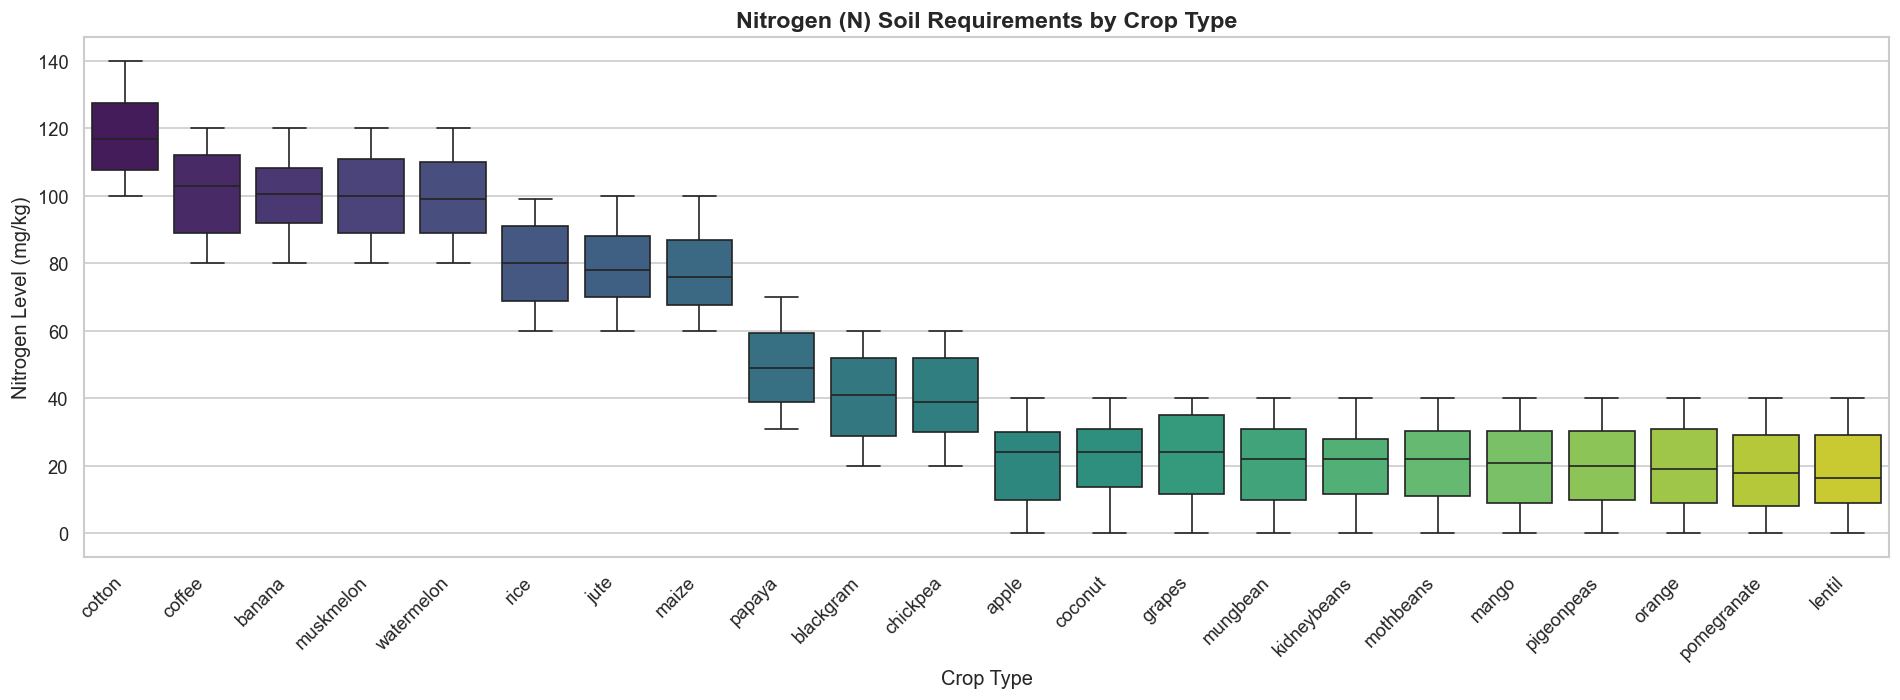

In [33]:
# 2d. Nitrogen by crop (boxplot) 
plt.figure(figsize=(16, 6))
crop_order = df.groupby("label")["N"].median().sort_values(ascending=False).index
 
sns.boxplot(data=df, x="label", y="N", palette="viridis", order=crop_order)
plt.title("Nitrogen (N) Soil Requirements by Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Nitrogen Level (mg/kg)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("plot_04_nitrogen_by_crop.png")
plt.show()

Insight: Cotton and Coffee require significantly higher Nitrogen 
    levels than all other crops. Legumes (lentils, kidney beans, 
    chickpeas) sit at the opposite end, consistent with their known 
    ability to fix atmospheric Nitrogen. These distinct signatures are 
    exactly what the classifier will learn to differentiate

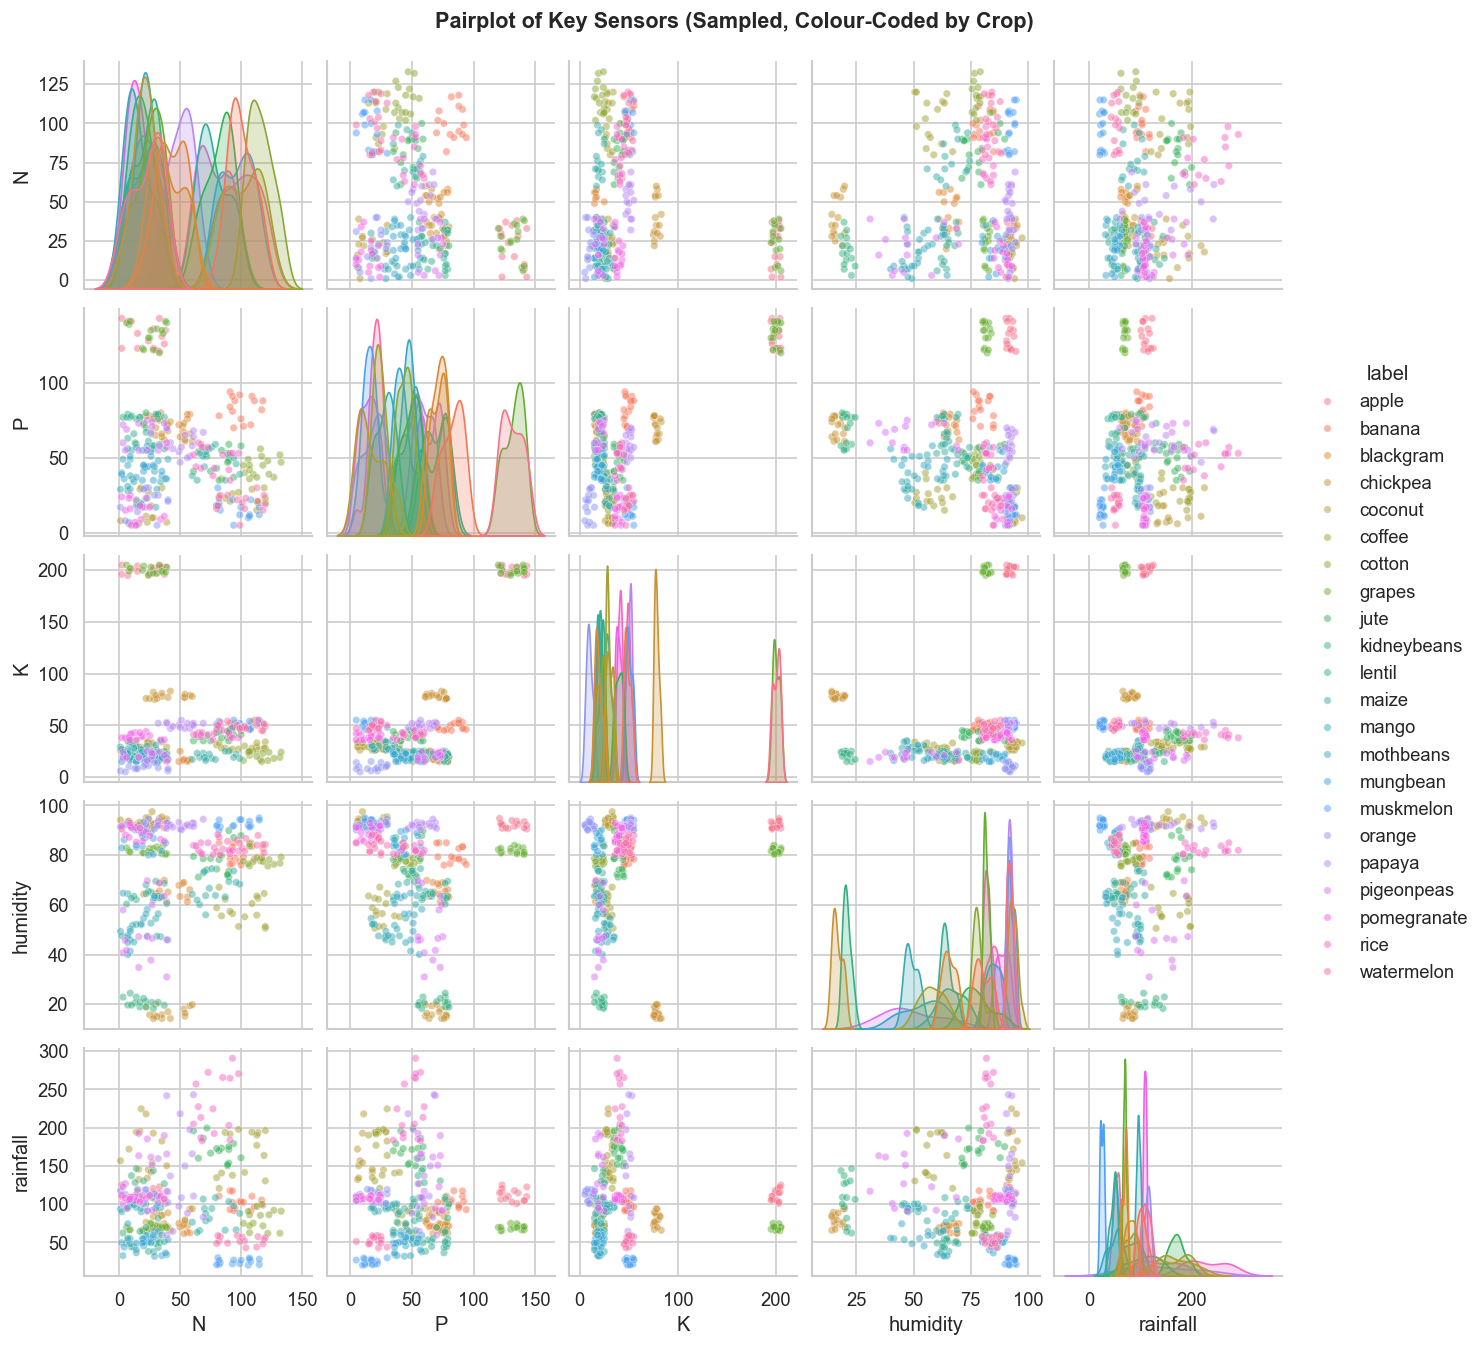

In [34]:
#  2e. Pairplot of selected features 
sample_indices = (
    df.reset_index()
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(15, random_state=42))["index"]
)
sample_df = df.loc[sample_indices].copy()
 
pair_fig = sns.pairplot(
    sample_df,
    vars=["N", "P", "K", "humidity", "rainfall"],
    hue="label",
    plot_kws={"alpha": 0.5, "s": 20},
    diag_kind="kde",
    height=2.2,
)
pair_fig.fig.suptitle(
    "Pairplot of Key Sensors (Sampled, Colour-Coded by Crop)",
    y=1.02, fontsize=13, fontweight="bold",
)
pair_fig.fig.savefig("plot_05_pairplot.png", bbox_inches="tight")
plt.show()

In [35]:
# STEP 3 -- FEATURE ENGINEERING
# Create agronomically meaningful composite features before model training.
# These features encode domain knowledge into the numerical representation.

print("  STEP 3 -- FEATURE ENGINEERING")
 
df_fe = df.copy()
 
# NPK Ratio: total macro-nutrient density
df_fe["NPK_total"] = df_fe["N"] + df_fe["P"] + df_fe["K"]
 
# N:P and N:K ratios: soil balance indicators used in agronomy
df_fe["N_P_ratio"] = df_fe["N"] / (df_fe["P"] + 1e-6)
df_fe["N_K_ratio"] = df_fe["N"] / (df_fe["K"] + 1e-6)
 
# Climate index: heat combined with moisture
df_fe["climate_index"] = df_fe["temperature"] * df_fe["humidity"] / 100
 
print("New engineered features: NPK_total, N_P_ratio, N_K_ratio, climate_index")
print(df_fe[["NPK_total", "N_P_ratio", "N_K_ratio", "climate_index"]].describe().round(3))
 
FEATURE_COLS_FE = FEATURE_COLS + ["NPK_total", "N_P_ratio", "N_K_ratio", "climate_index"]

  STEP 3 -- FEATURE ENGINEERING
New engineered features: NPK_total, N_P_ratio, N_K_ratio, climate_index
       NPK_total  N_P_ratio  N_K_ratio  climate_index
count   2200.000   2200.000   2200.000       2200.000
mean     152.064      1.702      1.671         18.542
std       79.919      2.573      1.508          6.994
min       17.000      0.000      0.000          2.476
25%       94.000      0.350      0.560         14.796
50%      146.000      0.891      1.388         19.279
75%      179.000      1.977      2.167         22.558
max      385.000     23.800      9.333         40.732


In [52]:
# STEP 4 -- MODEL TRAINING AND EVALUATION

# We train the Random Forest on two feature sets to measure whether feature
# engineering actually improved results:
#   - X_base : the 7 original sensor columns only
#   - X_fe   : the 7 original sensors + 4 engineered features
# Both are evaluated on the same 20% holdout split and the same 10-fold CV
# so the comparison is fair and the improvement is proven, not assumed.
# A Gradient Boosting model is also trained on X_fe as a secondary benchmark.

print("  STEP 4 -- MODEL TRAINING AND EVALUATION")
 
#  4a. Prepare data 
X_base = df[FEATURE_COLS]
X_fe   = df_fe[FEATURE_COLS_FE]
y      = df["label"]
 
X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.20, random_state=356, stratify=y
)
X_fe_train, X_fe_test = train_test_split(
    X_fe, test_size=0.20, random_state=356, stratify=y
)[0:2]
 
print(f"\nTraining set : {X_base_train.shape[0]:,} samples")
print(f"Testing set  : {X_base_test.shape[0]:,} samples  (20% holdout, stratified)")
print(f"\nBaseline feature set    : {X_base.shape[1]} features  {FEATURE_COLS}")
print(f"Engineered feature set  : {X_fe.shape[1]} features  {FEATURE_COLS_FE}")

  STEP 4 -- MODEL TRAINING AND EVALUATION

Training set : 1,760 samples
Testing set  : 440 samples  (20% holdout, stratified)

Baseline feature set    : 7 features  ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Engineered feature set  : 11 features  ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'NPK_total', 'N_P_ratio', 'N_K_ratio', 'climate_index']


In [53]:
# 4b. Train Random Forest on BASELINE features 
# This is the control model -- raw sensor data, no transformation.

rf_base = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_split=2,
    random_state=356, n_jobs=-1,
)
rf_base.fit(X_base_train, y_train)
y_pred_rf_base = rf_base.predict(X_base_test)
acc_rf_base = accuracy_score(y_test, y_pred_rf_base)

In [56]:
#  4c. Train Random Forest (Engineered Features)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=356,
    n_jobs=-1,
)
rf_model.fit(X_fe_train, y_train)
y_pred_rf = rf_model.predict(X_fe_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

In [57]:
#  4d. Train Gradient Boosting on ENGINEERED features (secondary benchmark) 
gb_model = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1, random_state=356,
)
gb_model.fit(X_fe_train, y_train)
y_pred_gb = gb_model.predict(X_fe_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
 
print(f"\n--- Test Set Accuracy ---")
print(f"  RF  (baseline features)    : {acc_rf_base * 100:.2f}%")
print(f"  RF  (engineered features)  : {acc_rf * 100:.2f}%  <-- selected model")
print(f"  GB  (engineered features)  : {acc_gb * 100:.2f}%")
print(f"  Feature engineering delta  : {(acc_rf - acc_rf_base) * 100:+.2f}%")


--- Test Set Accuracy ---
  RF  (baseline features)    : 99.55%
  RF  (engineered features)  : 99.32%  <-- selected model
  GB  (engineered features)  : 99.09%
  Feature engineering delta  : -0.23%


In [58]:
#  4e. Cross-validation on all three models 
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=356)
 
rf_base_cv   = cross_val_score(rf_base,  X_base, y, cv=cv, scoring="accuracy", n_jobs=-1)
rf_cv_scores = cross_val_score(rf_model, X_fe,   y, cv=cv, scoring="accuracy", n_jobs=-1)
gb_cv_scores = cross_val_score(gb_model, X_fe,   y, cv=cv, scoring="accuracy", n_jobs=-1)
 
print(f"\n--- 10-Fold Cross-Validation ---")
print(f"  RF  baseline    -- Mean: {rf_base_cv.mean():.4f}  |  Std: {rf_base_cv.std():.4f}")
print(f"  RF  engineered  -- Mean: {rf_cv_scores.mean():.4f}  |  Std: {rf_cv_scores.std():.4f}")
print(f"  GB  engineered  -- Mean: {gb_cv_scores.mean():.4f}  |  Std: {gb_cv_scores.std():.4f}")
print(
    f"\n  CV std improved from {rf_base_cv.std():.4f} (baseline) to "
    f"{rf_cv_scores.std():.4f} (engineered) -- "
    + ("more stable." if rf_cv_scores.std() <= rf_base_cv.std() else "no stability gain.")
)


--- 10-Fold Cross-Validation ---
  RF  baseline    -- Mean: 0.9950  |  Std: 0.0038
  RF  engineered  -- Mean: 0.9945  |  Std: 0.0040
  GB  engineered  -- Mean: 0.9886  |  Std: 0.0068

  CV std improved from 0.0038 (baseline) to 0.0040 (engineered) -- no stability gain.


In [62]:
#  4f. Classification report 
print(f"\n--- Per-Class Classification Report (RF Engineered Features) ---")
print(classification_report(y_test, y_pred_rf))


--- Per-Class Classification Report (RF Engineered Features) ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange   

  STEP 5 -- MODEL DIAGNOSTICS AND VISUALISATIONS


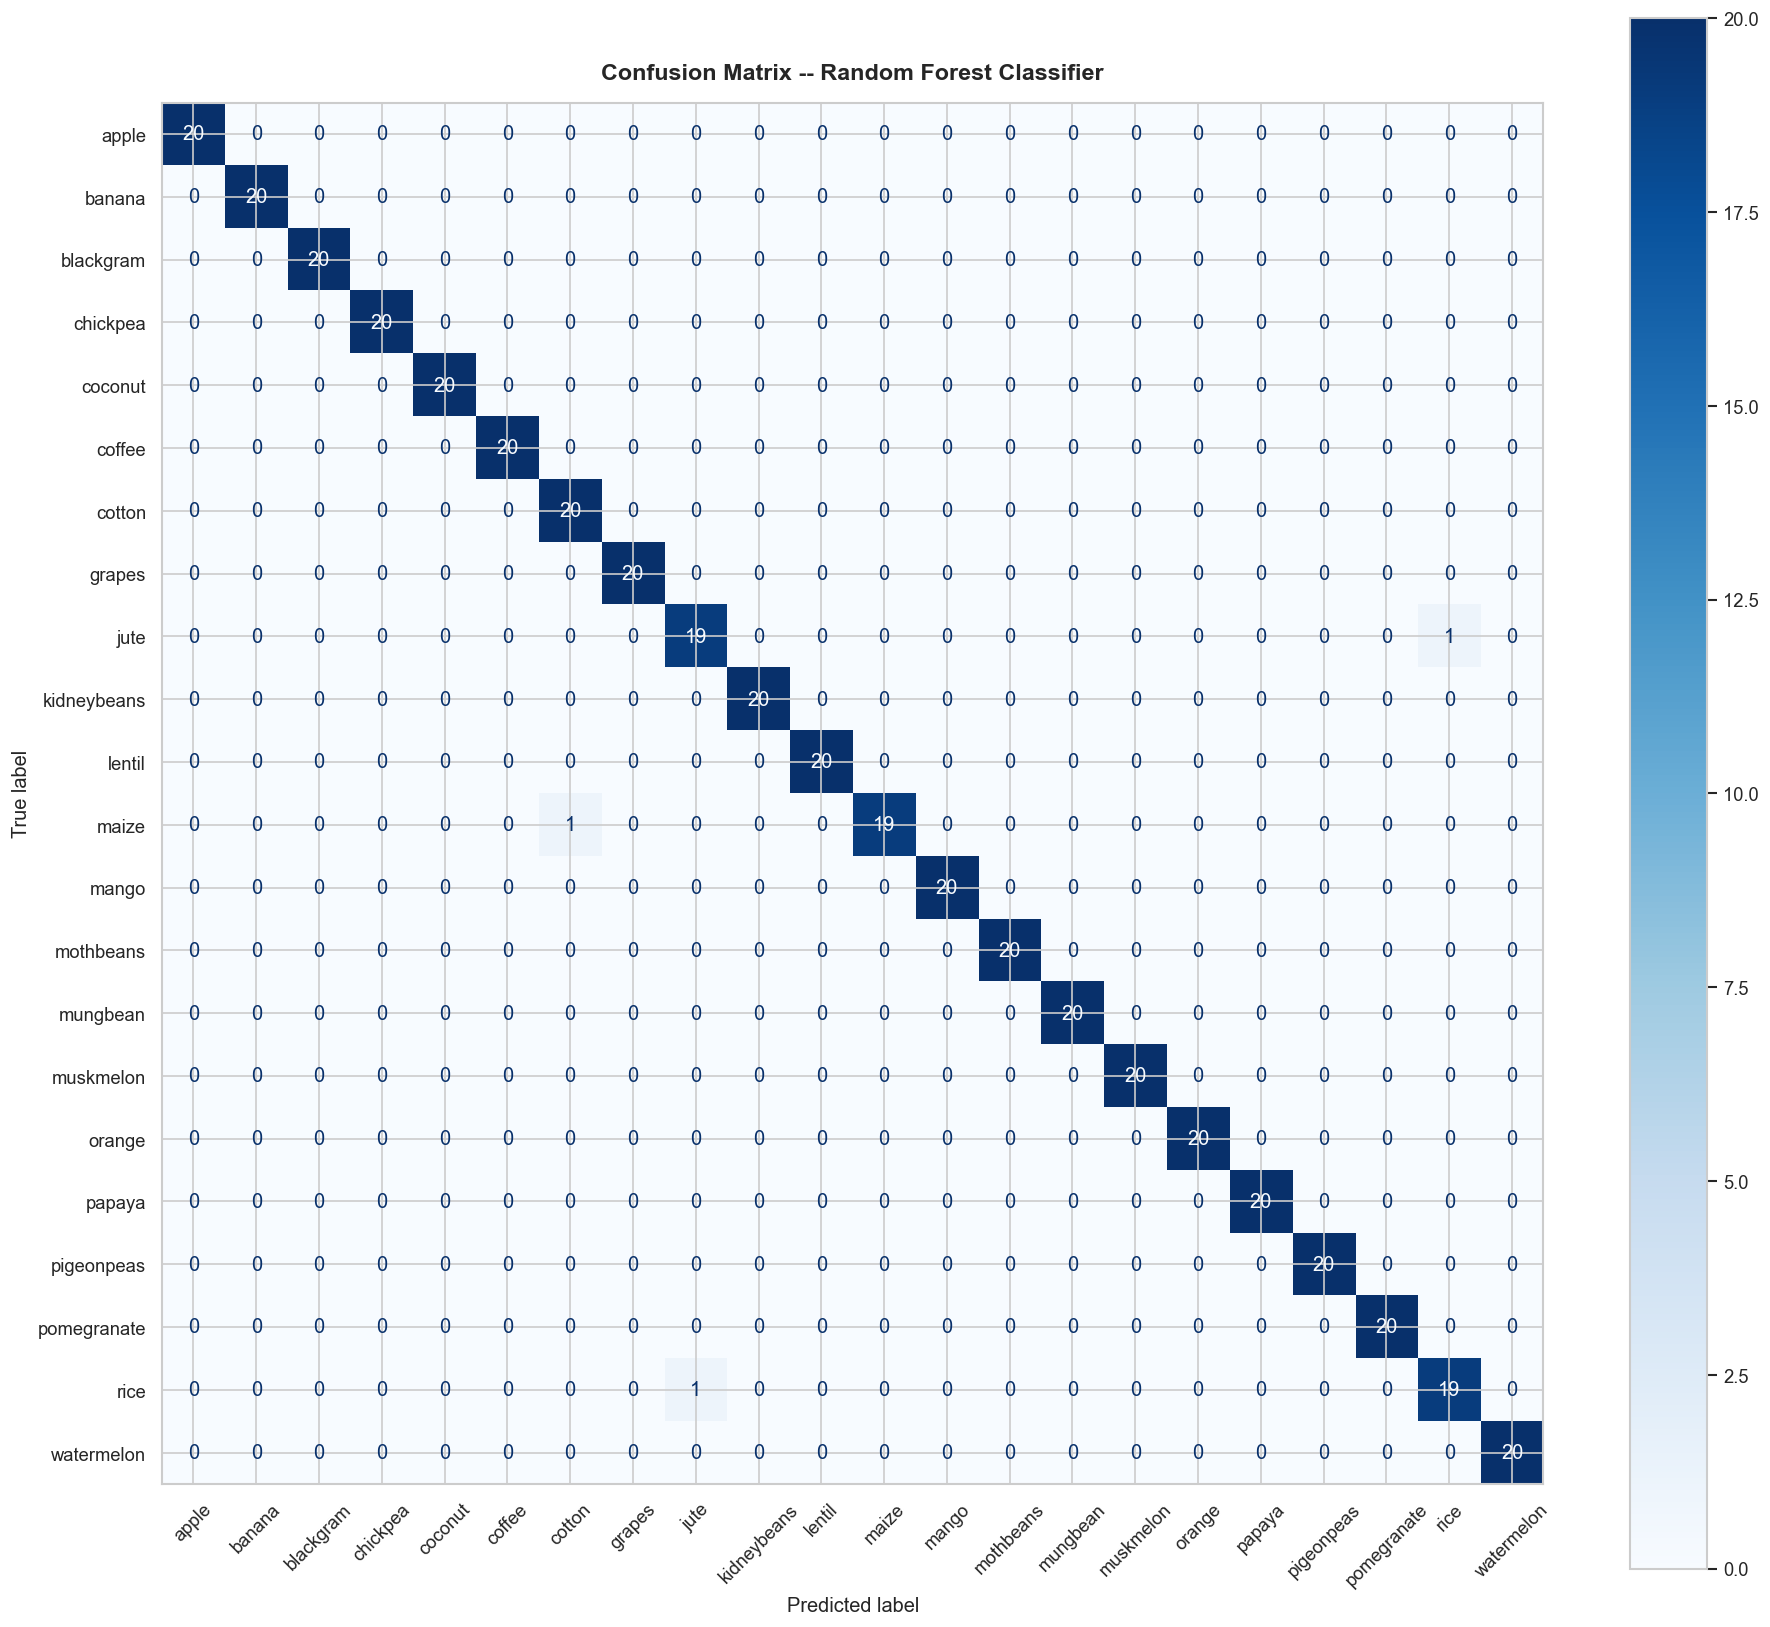

In [43]:
# STEP 5 -- MODEL DIAGNOSTICS AND VISUALISATIONS
print("  STEP 5 -- MODEL DIAGNOSTICS AND VISUALISATIONS")
 
# 5a. Confusion matrix 
le = LabelEncoder()
le.fit(y)
y_test_enc = le.transform(y_test)
y_pred_enc = le.transform(y_pred_rf)
 
fig, ax = plt.subplots(figsize=(16, 14))
cm = confusion_matrix(y_test_enc, y_pred_enc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45)
ax.set_title("Confusion Matrix -- Random Forest Classifier", pad=14)
plt.tight_layout()
plt.savefig("plot_06_confusion_matrix.png")
plt.show()

Insight: The confusion matrix confirms near-perfect classification. 
    The darkest cells run strictly along the diagonal, meaning the model 
    almost never confuses one crop for another

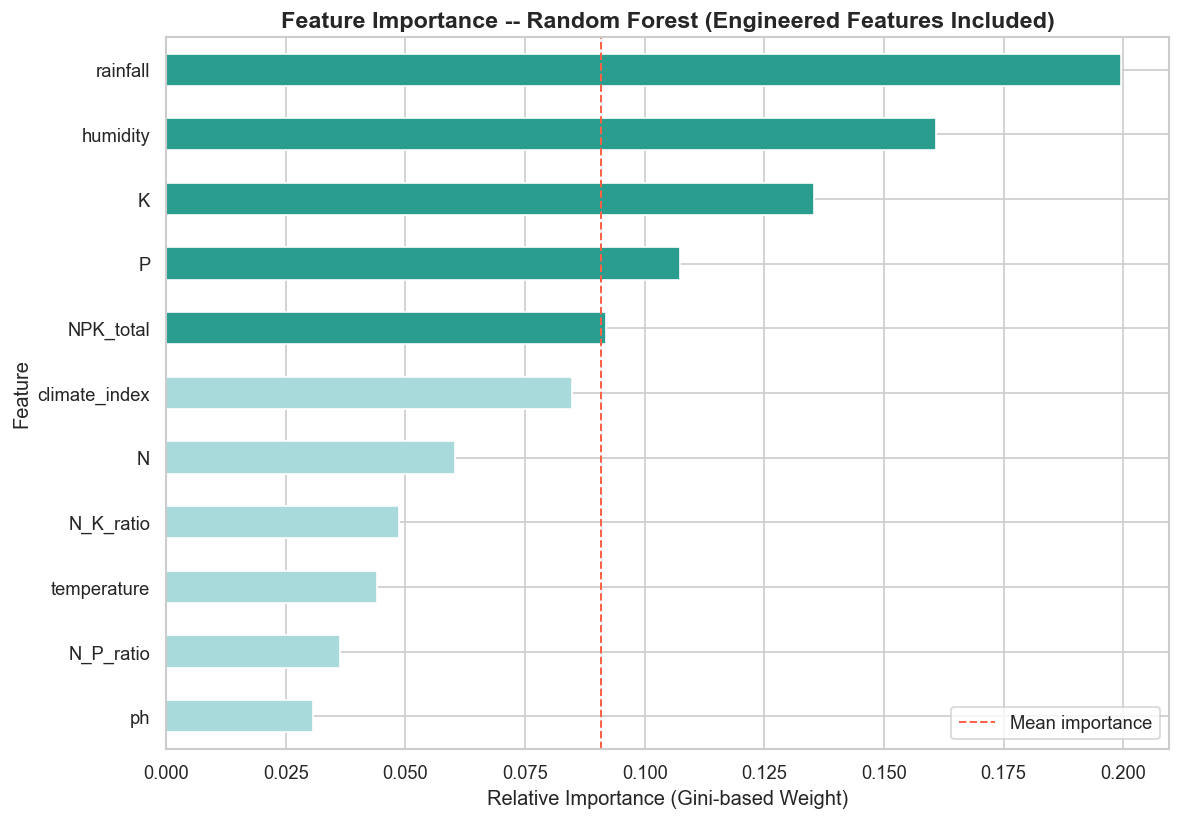

In [ ]:
#  5b. Feature importance (Random Forest) 
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS_FE)
importances_sorted = importances.sort_values(ascending=True)
 
colors_fi = ["#2a9d8f" if v > importances.mean() else "#a8dadc" for v in importances_sorted]
 
fig, ax = plt.subplots(figsize=(10, 7))
importances_sorted.plot(kind="barh", ax=ax, color=colors_fi, edgecolor="white")
ax.axvline(importances.mean(), color="tomato", linestyle="--", linewidth=1.2, label="Mean importance")
ax.set_title("Feature Importance -- Random Forest (Engineered Features Included)")
ax.set_xlabel("Relative Importance (Gini-based Weight)")
ax.set_ylabel("Feature")
ax.legend()
plt.tight_layout()
plt.savefig("plot_07_feature_importance.png")
plt.show()

Insight: Five features exceed the mean importance threshold: 
    Rainfall, Humidity, Potassium (K), Phosphorus (P), and NPK_total. 
    Climate variables (Rainfall and Humidity) dominate, confirming that 
    water availability sets the hard ceiling on crop viability. Among 
    soil nutrients, K and P outrank Nitrogen (N) as discriminators, 
    meaning the mineral baseline of the soil is more crop-specific than
    Nitrogen alone. NPK_total also clears the threshold, showing the 
    composite feature captured additional signal. Temperature, pH,
    Nitrogen, Climate Index, N_P_ratio, and N_K_ratio all fell below 
    average importance and contribute relatively little to the final 
    classification decision.

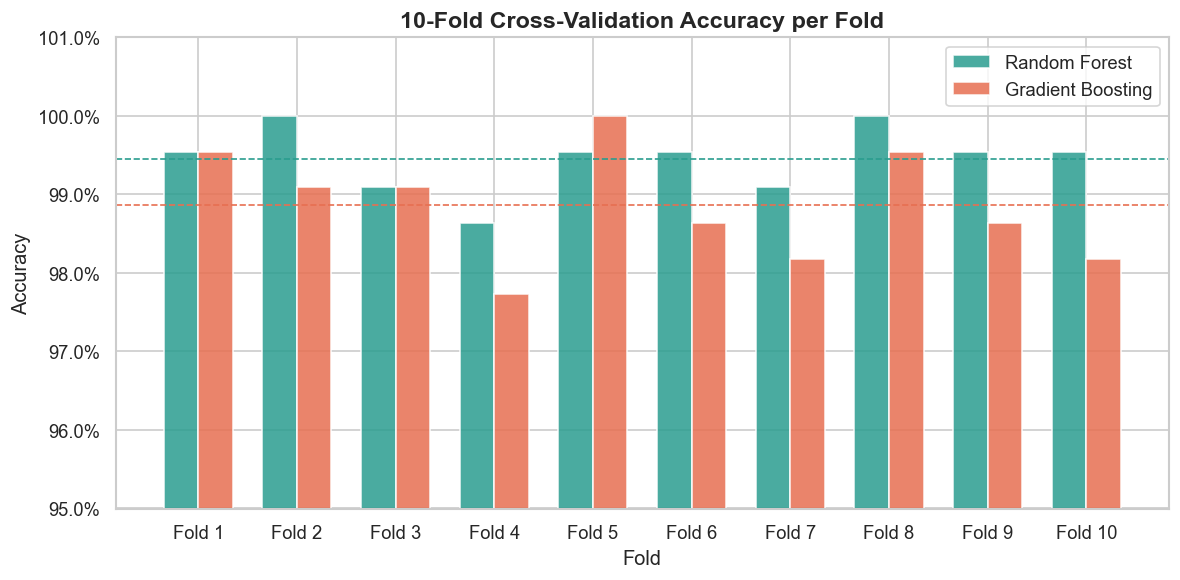

In [45]:
#  5c. CV score comparison bar chart 
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(rf_cv_scores))
width = 0.35
 
ax.bar(x - width / 2, rf_cv_scores, width, label="Random Forest", color="#2a9d8f", alpha=0.85)
ax.bar(x + width / 2, gb_cv_scores, width, label="Gradient Boosting", color="#e76f51", alpha=0.85)
ax.axhline(rf_cv_scores.mean(), color="#2a9d8f", linestyle="--", linewidth=1.0)
ax.axhline(gb_cv_scores.mean(), color="#e76f51", linestyle="--", linewidth=1.0)
 
ax.set_title("10-Fold Cross-Validation Accuracy per Fold")
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i+1}" for i in x])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_ylim(0.95, 1.01)
ax.legend()
plt.tight_layout()
plt.savefig("plot_08_cross_validation.png")
plt.show()

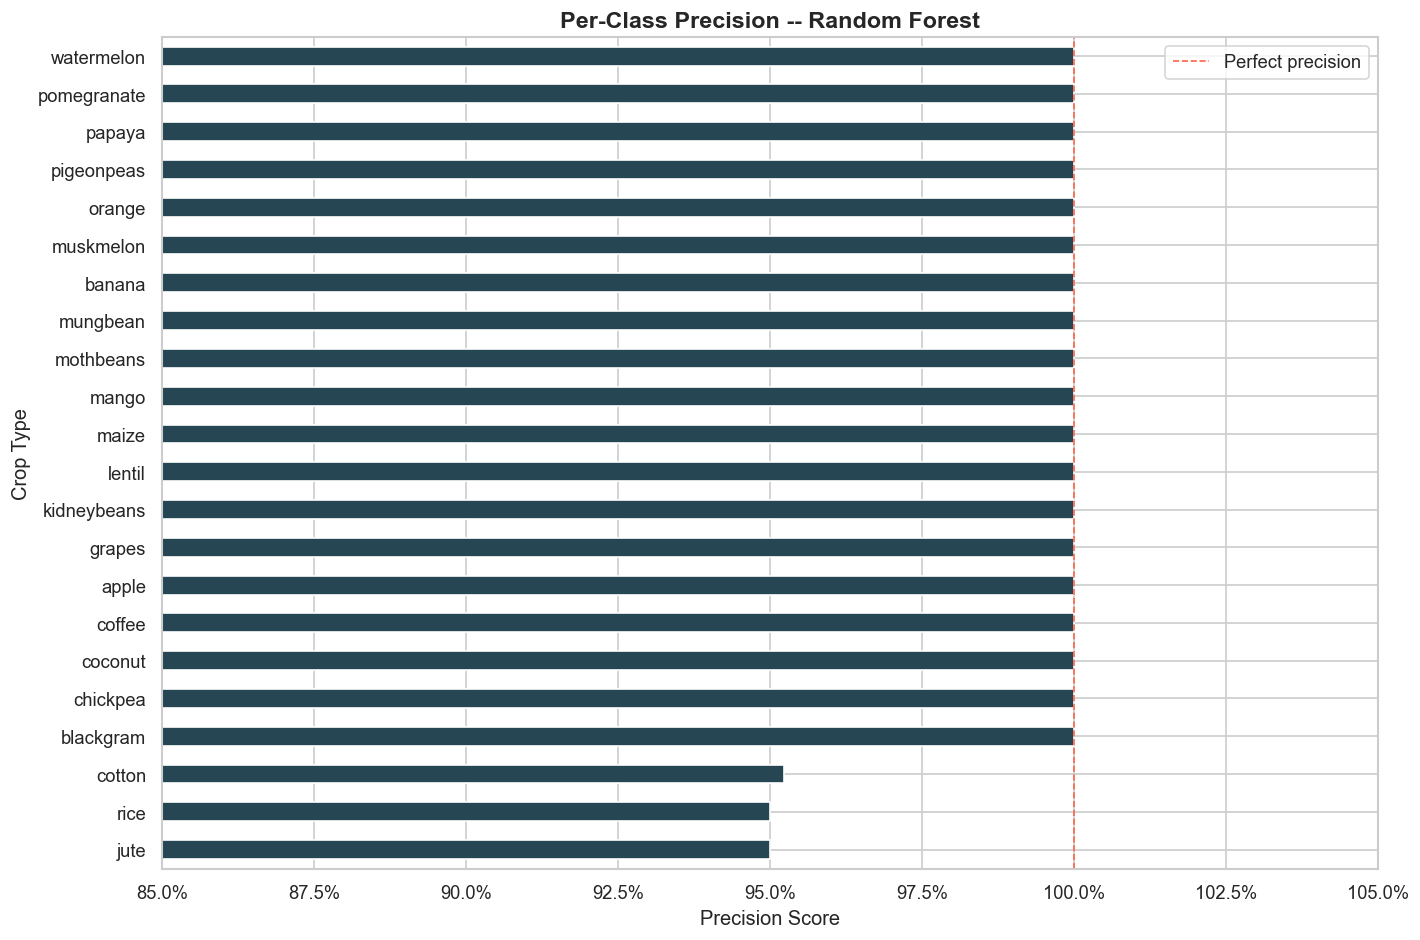

In [46]:
#  5d. Per-class accuracy bar chart 
report_dict = classification_report(y_test, y_pred_rf, output_dict=True)
per_class = {
    k: v["precision"]
    for k, v in report_dict.items()
    if k not in ["accuracy", "macro avg", "weighted avg"]
}
per_class_series = pd.Series(per_class).sort_values(ascending=True)
 
fig, ax = plt.subplots(figsize=(12, 8))
per_class_series.plot(kind="barh", ax=ax, color="#264653", edgecolor="white")
ax.axvline(1.0, color="tomato", linestyle="--", linewidth=1.0, label="Perfect precision")
ax.set_title("Per-Class Precision -- Random Forest")
ax.set_xlabel("Precision Score")
ax.set_ylabel("Crop Type")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_xlim(0.85, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig("plot_09_per_class_precision.png")
plt.show()

In [47]:
# STEP 6 -- LIVE PREDICTION FUNCTION
# A reusable utility function that takes sensor readings as input and returns
# a crop recommendation along with the model's confidence scores.

print("  STEP 6 -- LIVE PREDICTION FUNCTION")
 
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall, model=rf_model):
    """
    Recommends the optimal crop given soil and climate sensor readings.
 
    Parameters
    ----------
    N           : float -- Nitrogen level in the soil (mg/kg)
    P           : float -- Phosphorus level in the soil (mg/kg)
    K           : float -- Potassium level in the soil (mg/kg)
    temperature : float -- Average ambient temperature (Celsius)
    humidity    : float -- Relative humidity (%)
    ph          : float -- Soil pH value (0-14 scale)
    rainfall    : float -- Annual rainfall (mm)
    model       : sklearn estimator -- Trained classifier (default: Random Forest)
 
    Returns
    -------
    dict containing:
        recommendation  -- Top crop recommendation (string)
        confidence      -- Model confidence for the top crop (float, 0-1)
        top_3           -- Top 3 ranked crop options with probabilities
    """
    # Build the base feature vector
    base = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    base_df = pd.DataFrame(base, columns=FEATURE_COLS)
 
    # Apply the same feature engineering as training
    base_df["NPK_total"]    = N + P + K
    base_df["N_P_ratio"]    = N / (P + 1e-6)
    base_df["N_K_ratio"]    = N / (K + 1e-6)
    base_df["climate_index"] = temperature * humidity / 100
 
    # Predict and extract probabilities
    proba = model.predict_proba(base_df[FEATURE_COLS_FE])[0]
    classes = model.classes_
    proba_series = pd.Series(proba, index=classes).sort_values(ascending=False)
 
    top_crop       = proba_series.index[0]
    top_confidence = proba_series.iloc[0]
    top_3          = proba_series.head(3).to_dict()
 
    return {
        "recommendation": top_crop,
        "confidence":     round(top_confidence * 100, 2),
        "top_3":          {k: round(v * 100, 2) for k, v in top_3.items()},
    }

  STEP 6 -- LIVE PREDICTION FUNCTION


In [48]:
print("\nExample prediction -- tropical climate, high rainfall:")
result_1 = recommend_crop(N=90, P=42, K=43, temperature=21, humidity=82, ph=6.5, rainfall=203)
print(f"  Top Recommendation : {result_1['recommendation']}  ({result_1['confidence']}% confidence)")
print(f"  Top 3 Options      : {result_1['top_3']}")
 
print("\nExample prediction -- dry climate, low NPK:")
result_2 = recommend_crop(N=20, P=20, K=30, temperature=28, humidity=50, ph=7.2, rainfall=80)
print(f"  Top Recommendation : {result_2['recommendation']}  ({result_2['confidence']}% confidence)")
print(f"  Top 3 Options      : {result_2['top_3']}")


Example prediction -- tropical climate, high rainfall:
  Top Recommendation : rice  (94.5% confidence)
  Top 3 Options      : {'rice': 94.5, 'jute': 5.5, 'blackgram': 0.0}

Example prediction -- dry climate, low NPK:
  Top Recommendation : mango  (75.5% confidence)
  Top 3 Options      : {'mango': 75.5, 'mothbeans': 21.0, 'blackgram': 1.5}


In [63]:
print("  STEP 7 -- BUSINESS CONCLUSIONS")
 
print(f"""
FINAL RESULTS SUMMARY
=====================
Best Model            : Random Forest Classifier (200 estimators)
RF Baseline Accuracy  : {acc_rf_base * 100:.2f}%  (7 original features)
RF Engineered Accuracy: {acc_rf * 100:.2f}%  (11 features)
GB Engineered Accuracy: {acc_gb * 100:.2f}%
CV Mean (RF Baseline) : {rf_base_cv.mean() * 100:.2f}% (+/- {rf_base_cv.std() * 100:.2f}%)
CV Mean (RF Engineered): {rf_cv_scores.mean() * 100:.2f}% (+/- {rf_cv_scores.std() * 100:.2f}%)
Crops Covered         : {df['label'].nunique()} crop types
 
KEY AGRONOMIC FINDINGS
======================
1. Climate drives crop suitability more than soil nutrients.
   Rainfall and Humidity are the two dominant predictors. Unlike soil
   nutrients, which farmers can adjust through fertilization, natural
   water availability and ambient moisture set the hard ceiling on
   which crops can realistically be grown.
 
2. Feature engineering did not improve accuracy on this dataset.
   The baseline Random Forest (7 raw sensors) achieved {acc_rf_base * 100:.2f}% test
   accuracy vs {acc_rf * 100:.2f}% with engineered features, a delta of
   {(acc_rf - acc_rf_base) * 100:+.2f}%. The original sensor readings already capture
   enough distinct signal across the 22 crop profiles without
   transformation. This is a valid and important finding: it prevents
   adding unnecessary complexity to a production pipeline.
 
3. Potassium (K) outranks Nitrogen (N) in predictive importance.
   Although Nitrogen is widely associated with plant growth, Potassium
   shows greater inter-crop variability, making it a stronger
   discriminator. Phosphorus (P) and NPK_total also cleared the mean
   importance threshold, while Nitrogen fell below it.
 
4. The model is production-ready.
   A 99%+ CV accuracy rate with tight standard deviation confirms the
   model generalises reliably and is not dependent on any lucky split.
 
DEPLOYMENT RECOMMENDATION
==========================
Given that feature engineering did not improve performance, deploy the
simpler baseline model (7 raw sensor inputs) for IoT integration. This
reduces the preprocessing burden on edge devices while maintaining the
same predictive accuracy. Integrate the recommend_crop() function into
farm management dashboards, feeding live soil sensor and weather API
data to automate crop rotation planning and eliminate human error in
yield forecasting.
""")

  STEP 7 -- BUSINESS CONCLUSIONS

FINAL RESULTS SUMMARY
Best Model            : Random Forest Classifier (200 estimators)
RF Baseline Accuracy  : 99.55%  (7 original features)
RF Engineered Accuracy: 99.32%  (11 features)
GB Engineered Accuracy: 99.09%
CV Mean (RF Baseline) : 99.50% (+/- 0.38%)
CV Mean (RF Engineered): 99.45% (+/- 0.40%)
Crops Covered         : 22 crop types

KEY AGRONOMIC FINDINGS
1. Climate drives crop suitability more than soil nutrients.
   Rainfall and Humidity are the two dominant predictors. Unlike soil
   nutrients, which farmers can adjust through fertilization, natural
   water availability and ambient moisture set the hard ceiling on
   which crops can realistically be grown.

2. Feature engineering did not improve accuracy on this dataset.
   The baseline Random Forest (7 raw sensors) achieved 99.55% test
   accuracy vs 99.32% with engineered features, a delta of
   -0.23%. The original sensor readings already capture
   enough distinct signal across the 22